# Exploratory Data Analysis of Zomato Restaurant Dataset

## Objective
The objective of this project is to analyze the Zomato restaurant dataset, identify patterns and trends, create visualizations, and derive meaningful business insights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving zomato.csv to zomato (1).csv


In [3]:
df = pd.read_csv("zomato.csv", encoding='latin-1')

In [4]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


## Step 1: Data Inspection

In this section, we examine the structure, dimensions, data types, and quality of the dataset.

In [5]:
df.shape

(9551, 21)

In [6]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

### Findings from Data Inspection

- The dataset contains 9551 restaurant records and 21 columns.
- Numerical columns include ratings, votes, latitude, longitude, and cost.
- Text columns include city, cuisines, restaurant names, and delivery information.
- Only the 'Cuisines' column contains missing values.
- The dataset appears largely clean and ready for analysis.

In [8]:
df.isnull().sum()

,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0
Cuisines,9


## Step 2: Data Cleaning

The dataset was checked for missing values, duplicate records, and data quality issues before analysis.

In [9]:
df = df.dropna(subset=['Cuisines'])
df.shape

(9542, 21)

The dataset now contains 9542 records after removing rows with missing cuisine information.

In [10]:
df.isnull().sum()

,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0
Cuisines,0


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df['City'].value_counts().head(10)

,count
City,
New Delhi,5473
Gurgaon,1118
Noida,1080
Faridabad,251
Ghaziabad,25
Bhubaneshwar,21
Ahmedabad,21
Lucknow,21
Guwahati,21


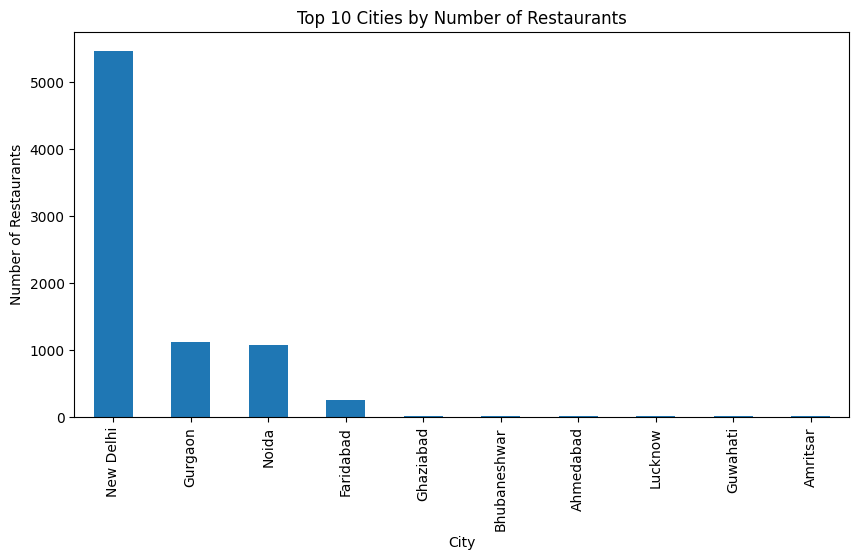

In [13]:
city_counts = df['City'].value_counts().head(10)

plt.figure(figsize=(10,5))
city_counts.plot(kind='bar')

plt.title('Top 10 Cities by Number of Restaurants')
plt.xlabel('City')
plt.ylabel('Number of Restaurants')

plt.show()

### Observation

New Delhi has the highest number of restaurants with 5473 records, followed by Gurgaon and Noida. This indicates that New Delhi is a major restaurant hub and dominates the dataset.

## EDA Question 2

Which cuisines are the most popular?

In [14]:
df['Cuisines'].value_counts().head(10)

,count
Cuisines,
North Indian,936
"North Indian, Chinese",511
Chinese,354
Fast Food,354
"North Indian, Mughlai",334
Cafe,299
Bakery,218
"North Indian, Mughlai, Chinese",197
"Bakery, Desserts",170


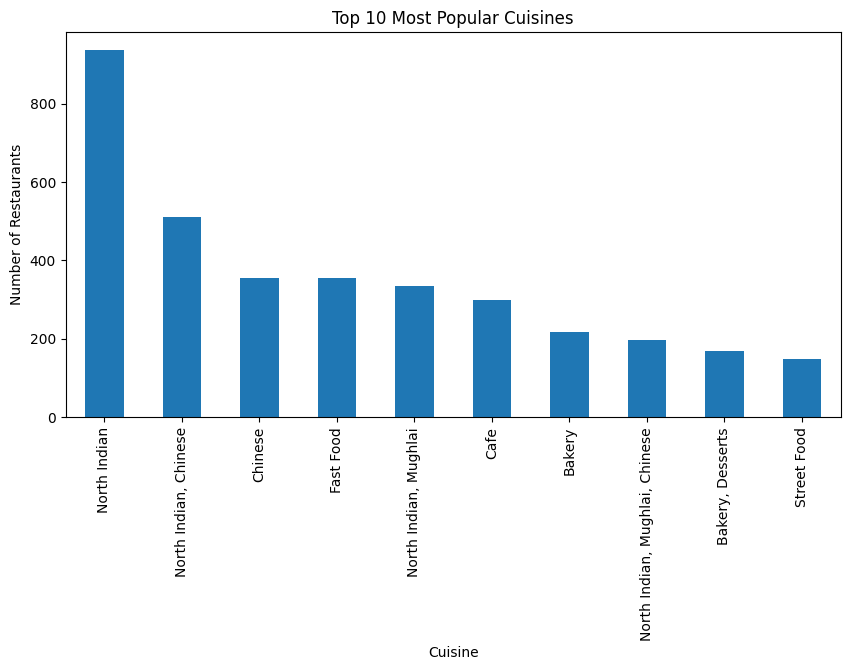

In [15]:
cuisine_counts = df['Cuisines'].value_counts().head(10)

plt.figure(figsize=(10,5))
cuisine_counts.plot(kind='bar')

plt.title('Top 10 Most Popular Cuisines')
plt.xlabel('Cuisine')
plt.ylabel('Number of Restaurants')

plt.show()

### Observation

North Indian cuisine is the most common cuisine in the dataset with 936 restaurants. Combinations such as North Indian and Chinese are also highly popular. This suggests that North Indian cuisine dominates the restaurant market and is widely preferred by customers.

## EDA Question 3

Do restaurants with online delivery receive better ratings?

In [16]:
df.groupby('Has Online delivery')['Aggregate rating'].mean()

,Aggregate rating
Has Online delivery,
No,2.463517
Yes,3.248837


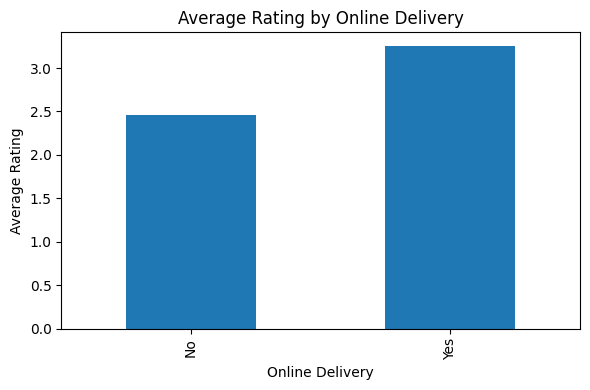

In [17]:
delivery_rating = df.groupby('Has Online delivery')['Aggregate rating'].mean()

plt.figure(figsize=(6,4))
delivery_rating.plot(kind='bar')

plt.title('Average Rating by Online Delivery')
plt.xlabel('Online Delivery')
plt.ylabel('Average Rating')
plt.tight_layout()

plt.show()

### Observation

The average rating of restaurants offering online delivery is 3.25, whereas restaurants without online delivery have an average rating of 2.46. This indicates that restaurants providing online delivery tend to receive higher customer ratings and may offer better customer convenience and satisfaction.

In [18]:
df.groupby('Price range')['Aggregate rating'].mean()

,Aggregate rating
Price range,
1,1.997476
2,2.941054
3,3.682633
4,3.817918


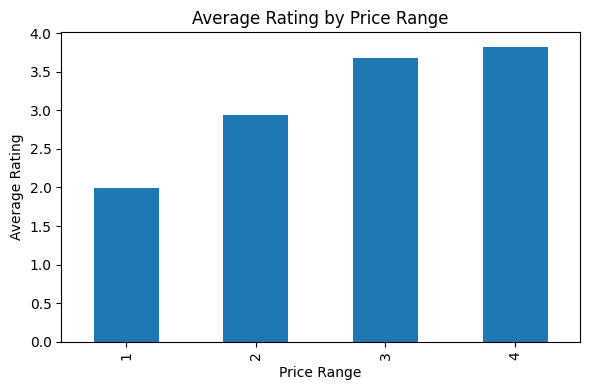

In [19]:
price_rating = df.groupby('Price range')['Aggregate rating'].mean()

plt.figure(figsize=(6,4))
price_rating.plot(kind='bar')

plt.title('Average Rating by Price Range')
plt.xlabel('Price Range')
plt.ylabel('Average Rating')

plt.tight_layout()
plt.show()

### Observation

Higher-priced restaurants tend to receive better ratings. The average rating rises from 1.99 in Price Range 1 to 3.82 in Price Range 4, indicating a positive relationship between restaurant pricing and customer satisfaction.

## EDA Question 5

Which restaurants have the highest customer ratings?

In [20]:
df[['Restaurant Name', 'Aggregate rating']]\
.sort_values(by='Aggregate rating', ascending=False)\
.head(10)

,Restaurant Name,Aggregate rating
9524,Gaga Manjero,4.9
3,Ooma,4.9
8,Spiral - Sofitel Philippine Plaza Manila,4.9
637,Sheroes Hangout,4.9
9514,Ministry of Crab,4.9
324,Ingleside Village Pizza,4.9
4298,Masala Library,4.9
304,Atlanta Highway Seafood Market,4.9
50,Garota de Ipanema,4.9
580,Punjab Grill,4.9


Multiple restaurants achieved the highest rating of 4.9, indicating consistently excellent customer satisfaction among top-performing restaurants.

## Visualization 1: Distribution of Restaurant Ratings (Histogram)

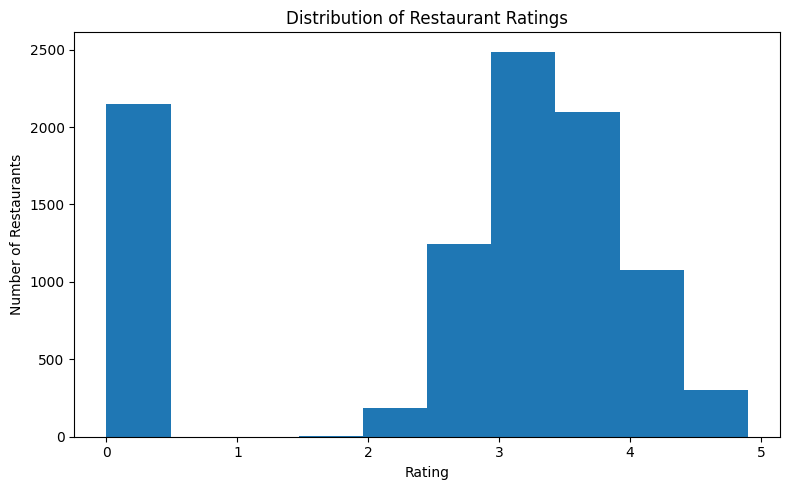

In [21]:
plt.figure(figsize=(8,5))

plt.hist(df['Aggregate rating'], bins=10)

plt.title('Distribution of Restaurant Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Restaurants')

plt.tight_layout()
plt.show()

### Observation

The histogram shows that most restaurants are concentrated in the rating range of approximately 3 to 4. This indicates that the majority of restaurants receive moderate to good customer ratings. Very few restaurants have extremely low or extremely high ratings, suggesting that most establishments provide a reasonably satisfactory dining experience.

## Visualization 2: Average Cost vs Restaurant Rating (Scatter Plot)

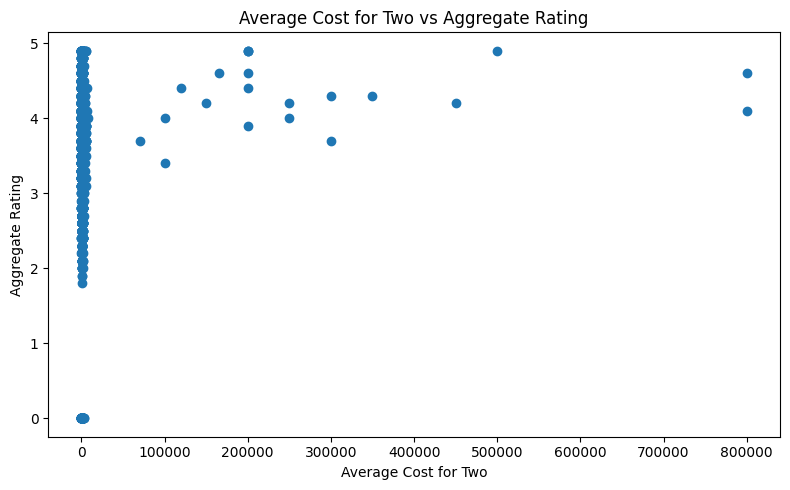

In [22]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['Average Cost for two'],
    df['Aggregate rating']
)

plt.title('Average Cost for Two vs Aggregate Rating')
plt.xlabel('Average Cost for Two')
plt.ylabel('Aggregate Rating')

plt.tight_layout()
plt.show()

### Observation

The scatter plot shows a weak positive relationship between the average cost for two people and restaurant ratings. Higher-priced restaurants generally tend to receive better ratings, but the relationship is not very strong. This suggests that while price may influence customer experience, factors such as food quality and service also play important roles.

## Visualization 3: Online Delivery Availability (Pie Chart)

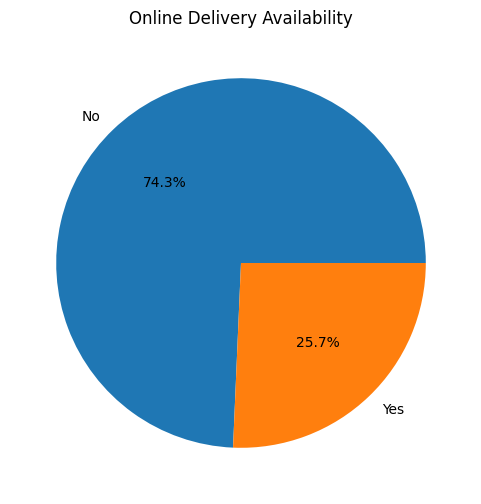

In [23]:
delivery_counts = df['Has Online delivery'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    delivery_counts,
    labels=delivery_counts.index,
    autopct='%1.1f%%'
)

plt.title('Online Delivery Availability')

plt.show()

### Observation

The pie chart shows that 74.3% of restaurants do not offer online delivery, while only 25.7% provide online delivery services. This indicates that online delivery is available in a minority of restaurants, suggesting significant potential for expansion of delivery-based services.

## Visualization 4: Correlation Heatmap

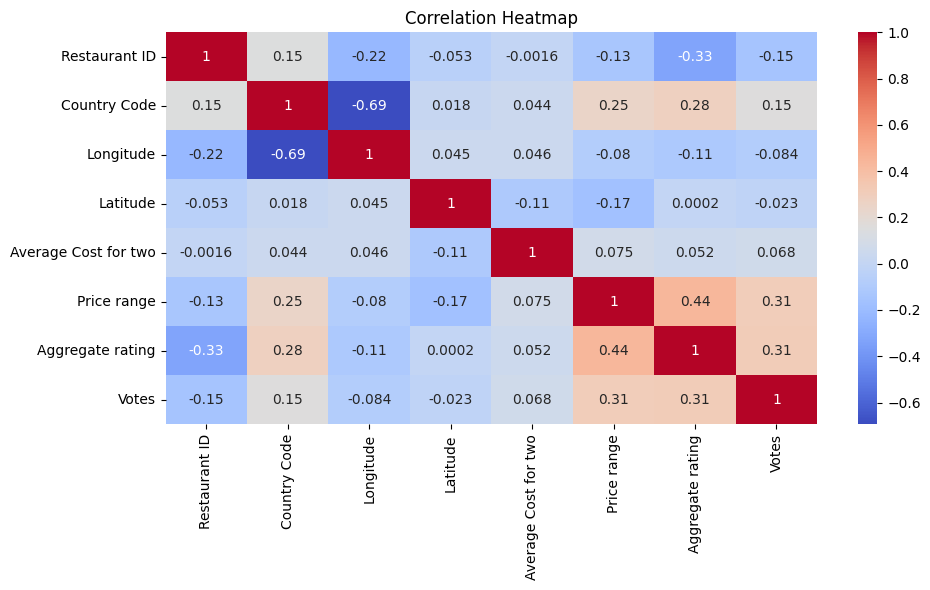

In [24]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()

### Observation

The heatmap shows that Price Range has the strongest positive correlation with Aggregate Rating (0.44), indicating that higher-priced restaurants generally receive better ratings. Votes also show a moderate positive correlation with ratings (0.31), suggesting that popular restaurants tend to be rated more highly. Most other variables have weak correlations, indicating limited direct relationships.
Price Range ↔ Aggregate Rating = 0.44

## Visualization 5: Average Rating by City (Line Chart)

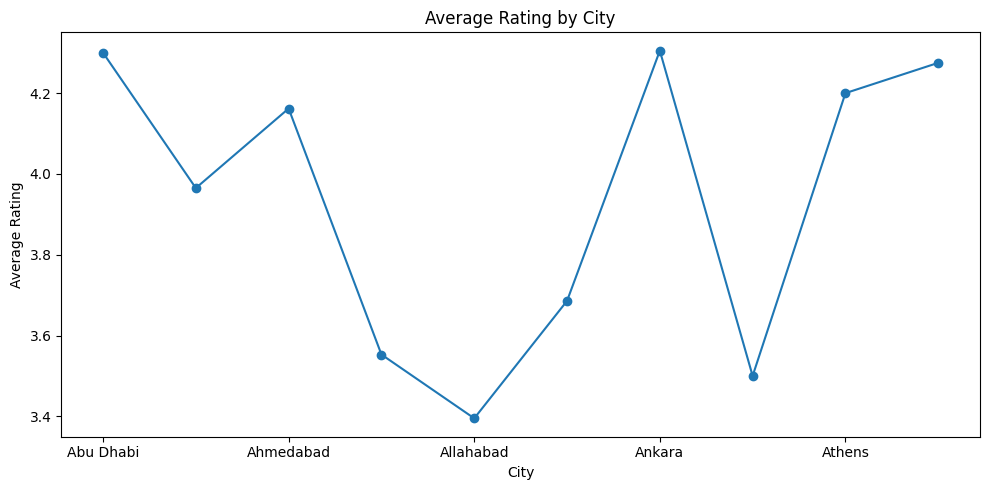

In [25]:
city_rating = df.groupby('City')['Aggregate rating'].mean().head(10)

plt.figure(figsize=(10,5))

city_rating.plot(kind='line', marker='o')

plt.title('Average Rating by City')
plt.xlabel('City')
plt.ylabel('Average Rating')

plt.tight_layout()
plt.show()

### Observation

The line chart shows variations in average restaurant ratings across different cities. Cities such as Ankara and Abu Dhabi have higher average ratings, while cities like Allahabad have comparatively lower ratings. This indicates that customer satisfaction levels differ across locations and may be influenced by local restaurant quality and service standards.

# Key Business Insights

### Insight 1
New Delhi dominates the dataset with 5473 restaurants, accounting for more than half of all restaurant records. This indicates that New Delhi is a major restaurant market and a key business region for Zomato.

### Insight 2
North Indian cuisine is the most popular cuisine in the dataset, followed by combinations of North Indian and Chinese cuisines. This suggests strong customer preference for North Indian food.

### Insight 3
Restaurants offering online delivery have a higher average rating (3.25) compared to restaurants without online delivery (2.46). This indicates that online delivery services may contribute to better customer satisfaction.

### Insight 4
Higher-priced restaurants generally receive better ratings. The average rating increases from 1.99 for Price Range 1 restaurants to 3.82 for Price Range 4 restaurants, suggesting a positive relationship between pricing and customer experience.

### Insight 5
The correlation heatmap shows that Price Range has the strongest positive relationship with Aggregate Rating (0.44). This suggests that customers often associate premium-priced restaurants with better dining experiences.

# Future Scope
Future analysis could include sentiment analysis of customer reviews, restaurant recommendation systems, and predictive modeling to estimate restaurant ratings.

# Conclusion
This project analyzed the Zomato restaurant dataset using data inspection, cleaning, exploratory data analysis, and visualization techniques. The analysis revealed important patterns related to restaurant locations, cuisines, online delivery services, pricing, and customer ratings. The findings show that customer satisfaction is influenced by factors such as service availability and price range, while cities and cuisines exhibit distinct market trends. These insights can help restaurant owners and food delivery platforms make informed business decisions.The analysis demonstrates how customer ratings are influenced by restaurant pricing, delivery services, and location-based factors.